In [63]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84_new import variables, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers, ambient_temp, v_conv
from kalman_filter_2 import kalman_filter as kf
from sklearn.metrics import mean_squared_error

### Testing the model

In [64]:
measurements = xr.open_mfdataset(r'cesar_surface_meteo_lc1_t10_v1.0_202407.nc')

In [65]:
measurements

<xarray.Dataset> Size: 411kB
Dimensions:          (time: 4464, day_in_time_interval: 31, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:...
Dimensions without coordinates: day_in_time_interval, nv
Data variables: (12/22)
    iso_dataset      |S1 1B ...
    product          |S1 1B ...
    station_details  |S1 1B ...
    date             (time) int32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    valid_dates      (day_in_time_interval) int8 31B dask.array<chunksize=(31,), meta=np.ndarray>
    time_bnds        (time, nv) datetime64[ns] 71kB dask.array<chunksize=(4464, 2), meta=np.ndarray>
    ...               ...
    F010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    IF010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    D010             (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    ID010            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002            (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

In [66]:
slice_str = "2024-07-01 00:00:00, 2024-07-04 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

#### Radiometer LWC 

In [67]:
cabaw = xr.open_mfdataset(r'data\Cabaw_radiometer\*.nc')
reference_date = np.datetime64("2024-07-01")

# Convert minutes into datetime
#datetime_values = reference_date + measurements.time.astype("timedelta64[m]")
#measurements['time'] = datetime_values

july = cabaw.sel(time=slice(*slice_tuple))

In [68]:
#var = ['temperature','pressure','humidity','rain_rate']
var = ['TA002','P0','TD002','RH002']
measurements = measurements[var]
measurements = measurements.dropna(dim='time',how='any')
measurements_used = measurements.sel(time=slice(*slice_tuple))

In [69]:
measurements

<xarray.Dataset> Size: 107kB
Dimensions:  (time: 4464)
Coordinates:
  * time     (time) datetime64[ns] 36kB 2024-07-01 ... 2024-07-31T23:49:59.92...
Data variables:
    TA002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    P0       (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    TD002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
    RH002    (time) float32 18kB dask.array<chunksize=(4464,), meta=np.ndarray>
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.4
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20240826 10:49:12 (UTC)
    references:               cesar_surface_meteo_lc1_t10_v1.0.pdf @ http://w...
    history:                  Continuous observations are performed, gap fill...

#Kalman filter measurements

kf_measurements = measurements['rain_rate'].values[7000:10000:30]

In [70]:
parsivel_1 = xr.open_dataset(r'data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values

In [71]:
rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=measurements.time,method='nearest')

In [72]:
#kf_measurements = rain_rate.isel(time=slice(None, None, 6))
kf_measurements_used = rain_rate.sel(time=slice(*slice_tuple))

In [73]:
kf_measurements_used

<xarray.DataArray 'rainfall_rate_32bit' (time: 576)> Size: 2kB
[576 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[s] 5kB 2024-07-01 ... 2024-07-04T23:50:00
Attributes:
    long_name:  average rainfall rate over the last minute
    units:      mm/h
    comment:    Field 01 in technical documentation

#inputs

#temperature on the ground
T_surf_C = measurements_used['temperature'].values #[C]
T_surf = T_surf_C + 273.15    # [K]

#pressure
p_surf = measurements_used['pressure'].values*100  #[Pa]

#dew point temperature
RH = measurements_used['humidity'].values
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
Sigma = np.zeros(len(T_surf))
Sigma[0] = 5 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [74]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = july.lwp[0]   #initial state in kg/m2
#X = july.lwp.sel(time=measurements_used.time,method='nearest').values
Sigma = np.zeros(len(T_surf))
Sigma[0] = 1 #initial state covariance in kg/m2

#timestep
dt= 600      #timestep in s

In [75]:
RH = measurements_used['RH002'].values
T_surf_C =T_surf - 273.15
alpha_T = 17.27*T_surf_C/(T_surf_C + 237.7) + np.log(RH/100) #from http://dx.doi.org/10.31648/ts.5425
T_d_arr_2 = 237.7*alpha_T/(17.27 - alpha_T) + 273.15      #[K]

In [76]:
july.lwp.sel(time=measurements_used.time,method='nearest').values.min()

nan

In [ ]:
#loop for finding the precipitation given the T_0 and p
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
t_lower =0
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))
j = 0
Q = 0.32
for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    T_l_up = ambient_temp(T_0,p_0,p_s,T_s)
    T_t_up = ambient_temp(T_0,p_0,p_t,T_t)
    #print(T_l_up,T_s)
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr_l = v(T_s,T_l_up)
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    Z_m = cloud_heights(T_s,T_m,T_0,p_s,p_s_up,p_0)[0]
    v_updr = v_conv(v_updr_l,T_m,T_s_up,Z_c,Z_m)
    #print(v_updr,v_updr_t)
    v_updr_t = v_conv(v_updr_l,T_t,T_t_up,Z_c,Z_c)
    O_b,O_t,h_v = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()   #outflows and sources of water
    
    f_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr_l)
        
    h_arr[i] = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()[2]
    #precipitation in kg/m2/s
    #P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l,v_updr_t,2).calculate_phi()*3
    #P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l).calculate_phi()*X[i] #*X[i] if we are using the updated state
    #print(phi(T_0, p_0, T_d, Z_b, Z_c,v_updr_l).calculate_phi()*3600)
    #state without Kalman filter
    
    #print(T_s_up,T_m)
    #state with Kalman filter   
    if i>=0:
        if (i>0):
            #X[i] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            #Sigma[i] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)

            P_0[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()*3
            P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()*X[i]
        if (((i%6==0)&(i>0)):
            # we assume that we receive a precipitation update every 60mins
            j = i
            print(j)
            
            phi_kf = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr,v_updr_l,v_updr_t,2).calculate_phi()
            h_kf = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()[2]
            f_kf = f(T_d,p_0,p_t,T_t,rho,v_updr_l)
            
            kalman_f = kf(X[i], Sigma[i], dt,h_kf,phi_kf,f_kf,kf_measurements_used[j].values) 
            X[i],Sigma[i],X_apr = kalman_f.update()
            #print(X[i],X_apr)

        #print(h_arr[i])

        
        if i<(len(T_surf)-1):
            print(np.trapz([f_arr[j:i+1] - h_arr[j:i+1]*X[j:i+1]], dx=dt))
            X[i+1] = max(0,X[i] + (np.trapz([f_arr[j:i+1]], dx=dt)) - np.trapz([h_arr[j:i+1]*X[j:i+1]], dx=dt))
            Sigma[i+1] = Sigma[i] + 2*np.trapz([h_arr[j:i+1]*Sigma[j:i+1]], dx=dt) + Q*dt*(i - j)
            #print(X[i],X_apr)



c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\GB84_new.py:253: RuntimeWarning: overflow encountered in exp
  /(gamma**5*np.exp(gamma*self.N_v2))+ self.N_v2/(4*gamma**4) + 1/gamma**5


[0.]
[-0.65148619]
[-0.96987922]
[-0.95681308]
[-0.94412584]
[-0.93165822]
6
[0.]
[0.01129587]
[-1.11308276]
[-2.23806534]
[-2.22807592]
[-2.21859838]
12
[0.]
[0.00951024]
[-0.93048912]
[-1.87089655]
[-1.86267357]
[-1.85447637]
18
[0.]
[0.00896137]
[-0.90184139]
[-1.81250108]
[-1.80336439]
[-1.79522878]
24
[0.]
[0.00761903]
[-0.76969444]
[-1.54609533]
[-1.53586059]
[-1.5247173]
30
[0.]
[0.01220562]
[-1.25191658]
[-2.51517169]
[-2.5008517]
[-2.48589428]
36
[0.]
[0.01629256]
[-1.61354368]
[-3.24323603]
[-3.2271182]
[-3.21338049]
42
[0.]
[0.01294062]
[-1.31891481]
[-2.65157593]
[-2.63881241]
[-2.62471697]
48
[0.]
[0.01416608]
[-1.43144008]
[-2.87662795]
[-2.86156038]
[-2.84568807]
54
[0.]
[0.01706534]
[-1.64176913]
[-3.30022616]
[-3.28183885]
[-3.26349971]
60
[0.]
[0.01884746]
[-1.78045203]
[-3.57928892]
[-3.55947788]
[-3.53971868]
66
[0.]
[0.02000766]
[-1.80270056]
[-3.62529543]
[-3.60496575]
[-3.58458125]
72
[0.]
[0.02063759]
[-1.85335924]
[-3.72743913]
[-3.70683364]
[-3.68615145]
78
[0

In [78]:
Z_b

514.3974026189956

In [79]:
import numpy as np
a = np.array([1,2,3])
j = sum(a[0:2])
print(j)

3


In [80]:
X[-1]

0.0

### Plots and results

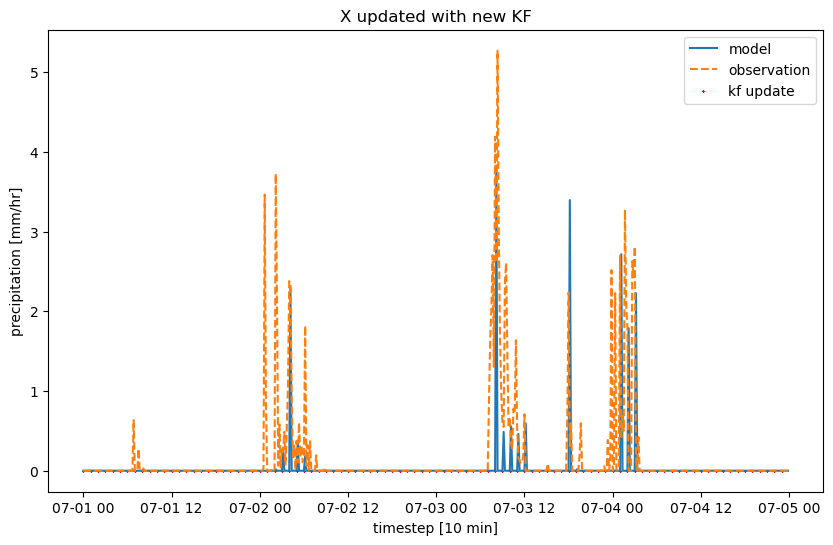

In [81]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))

plt.plot(measurements_used.time,P*3600,label='model')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(measurements_used.time,rain_rate.sel(time=slice(*slice_tuple)),label='observation',linestyle='dashed')
plt.scatter(measurements_used.time[0::6],np.zeros((len(kf_measurements_used[0::6]))),label='kf update',marker='x',s=0.6,color='red')

plt.xlabel('timestep [10 min]')
plt.title('X updated with new KF')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
plt.show()


In [82]:
rmse = mean_squared_error(rain_rate.sel(time=slice(*slice_tuple)),P*3600)
print(rmse)

0.3977857621228083


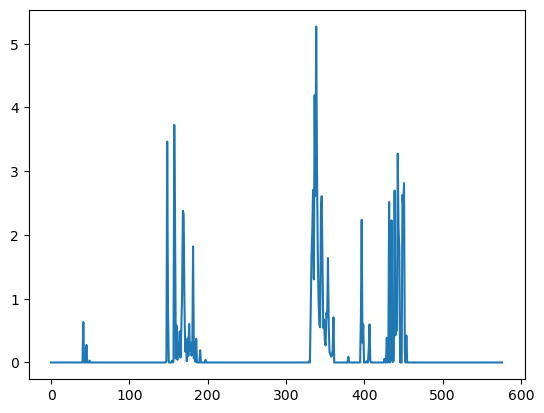

In [83]:
plt.plot(t_step,rain_rate.sel(time=slice(*slice_tuple)),label='observation')

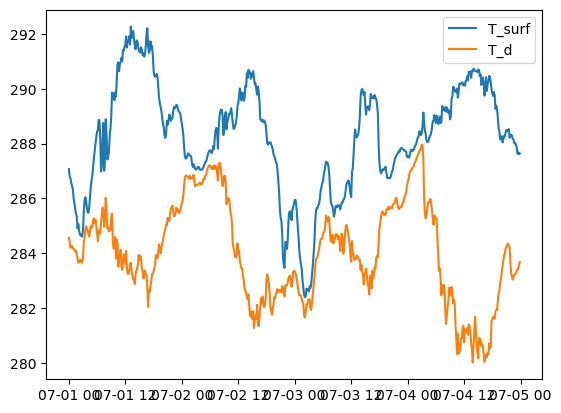

In [84]:
plt.plot(measurements_used.time,T_surf,label='T_surf')
plt.plot(measurements_used.time,T_d_arr,label='T_d')
plt.legend()

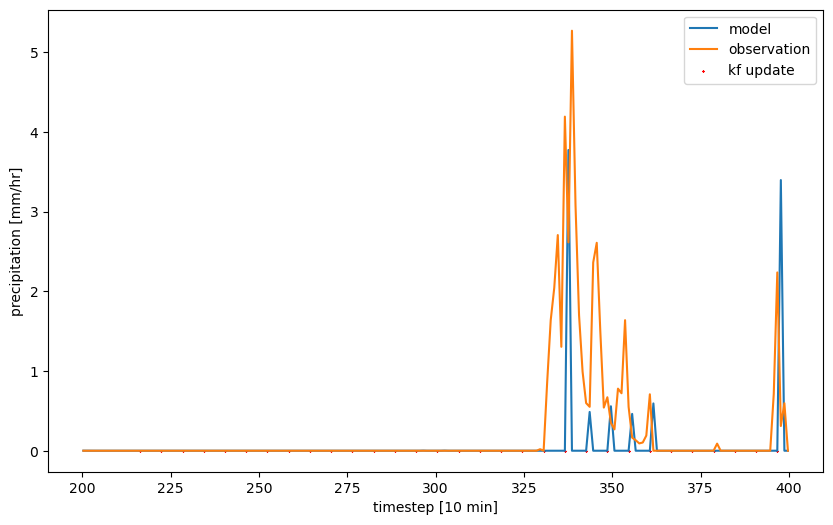

In [85]:
#zooming when no rain is observed
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))
plt.plot(t_step[200:400],P[200:400]*3600,label='model')
plt.plot(t_step[200:400],rain_rate.sel(time=slice(*slice_tuple))[200:400],label='observation')
plt.scatter(t_step[0::6][36:67],np.zeros((len(kf_measurements_used[0::6][36:67]))),label='kf update',marker='x',s=0.6,color='red')
plt.legend()
plt.xlabel('timestep [10 min]')
plt.ylabel('precipitation [mm/hr]')
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

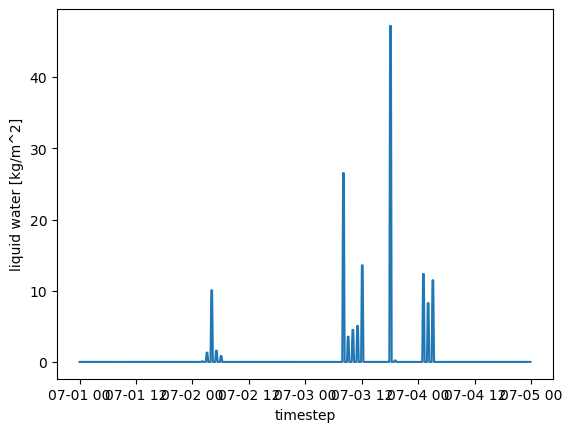

In [86]:
#state evolution

plt.plot(measurements_used.time,X)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

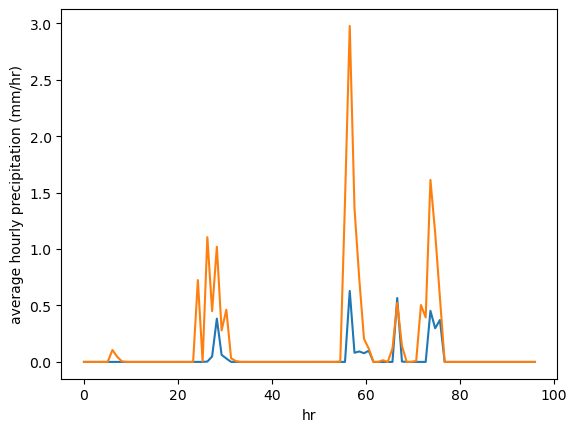

In [87]:
Pmeas = rain_rate.sel(time=slice(*slice_tuple))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

In [88]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = variables(T_0, T_d, p_0, obs=False).run()
    T_l_up = ambient_temp(T_0,p_0,p_s,T_s)
    T_t_up = ambient_temp(T_0,p_0,p_t,T_t)
    #print(T_l_up,T_s)
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr_l = v(T_s,T_l_up)
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    Z_m = cloud_heights(T_s,T_m,T_0,p_s,p_s_up,p_0)[0]
    v_updr = v_conv(v_updr_l,T_m,T_s_up,Z_c,Z_m)
    print(v_updr,v_updr_t)
    v_updr_t = v_conv(v_updr_l,T_t,T_t_up,Z_c,Z_c)
    O_b,O_t,h_v = h_out(v_updr,v_updr_l,v_updr_t,Z_c,2).run()   #outflows and sources of water
    v_arr[i] = v_updr
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


[112.62917881] [2283.27228555]
[292.54332159]
[112.62586383] [2496.9075561]
[292.53471124]
[111.72697049] [2488.79908968]
[290.19992336]
[112.49178728] [2456.29311092]
[292.18646048]
[112.89055781] [2476.3137877]
[293.22222808]


c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\GB84_new.py:253: RuntimeWarning: overflow encountered in exp
  /(gamma**5*np.exp(gamma*self.N_v2))+ self.N_v2/(4*gamma**4) + 1/gamma**5


[112.85740414] [2486.72260877]
[293.13611465]
[113.86799255] [2481.51781709]
[295.76101961]
[114.15943521] [2504.31075784]
[296.51801353]
[114.4249964] [2508.18358923]
[297.20778285]
[115.28535284] [2510.81615566]
[299.44247492]
[114.63553094] [2532.96201039]
[297.75462583]
[115.37855579] [2508.55912662]
[299.68456051]
[113.9711685] [2518.18830333]
[296.02900909]
[114.78175196] [2476.74945818]
[298.13442067]
[115.64356507] [2495.55177848]
[300.37289628]
[115.51731085] [2519.84557688]
[300.04496324]
[115.70647272] [2513.90229109]
[300.53629279]
[115.47292177] [2521.26016373]
[299.92966692]
[115.7312956] [2511.03879189]
[300.60076779]
[116.51150842] [2528.62384139]
[302.6272946]
[116.34820624] [2577.30587878]
[302.20313308]
[117.58918908] [2585.1243373]
[305.42646514]
[118.74923755] [2630.26786027]
[308.43957806]
[119.21439839] [2665.66991093]
[309.64778801]
[119.32338173] [2671.95594374]
[309.93086163]
[118.34431888] [2670.93894538]
[307.38784126]
[117.41010617] [2636.74774695]
[304.961

Text(0, 0.5, 'updraft velocity [m/s]')

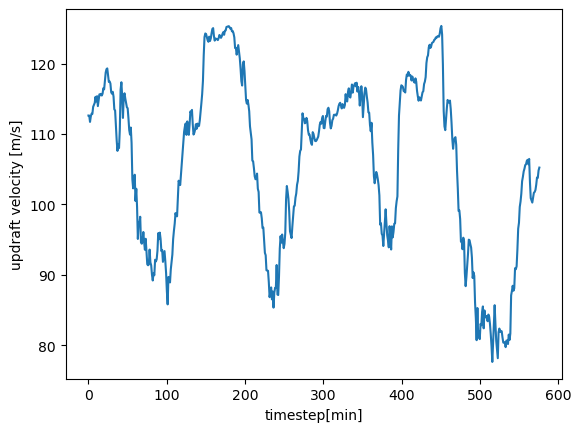

In [89]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

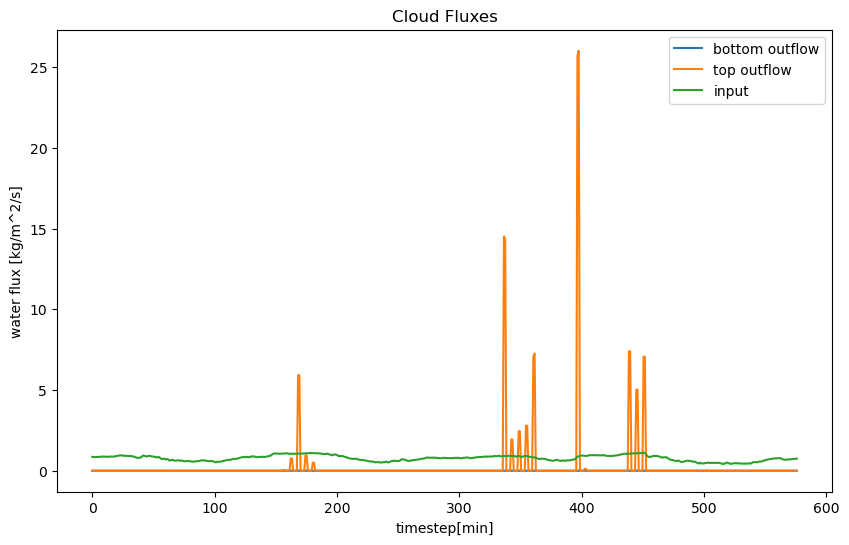

In [90]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')

In [91]:
O_b

0.9976056025812775

In [92]:
X[i]*non_dim_numbers(v_updr)[0]/Z_c

array([0.])

In [93]:
T_t

array([247.2348241])